In [ ]:
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tensorflow.keras.datasets import imdb
from wordcloud import WordCloud

import numpy as np

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")


def ensure_stop_words_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


def ensure_punkt_tab_downloaded():
    try:
        nltk.data.find("tokenizers/punkt")
    except LookupError:
        nltk.download("punkt")


ensure_stop_words_downloaded()
ensure_punkt_tab_downloaded()

## Phase 1 : Exploration et Préparation

### 1.1 - Chargement et exploration des données
- Chargez un corpus de critiques
- Explorez la structure : nombre de données, label distribution
- Analysez la longueur des critiques
- Vérifiez l'équilibre des classes

In [72]:
(X_train_idx, y_train), (X_test_idx, y_test) = imdb.load_data(num_words=10000)

word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}


def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])


X_train_text = [decode_review(review) for review in X_train_idx]
X_test_text = [decode_review(review) for review in X_test_idx]

df_train = pd.DataFrame({"review": X_train_text, "sentiment": y_train})
df_test = pd.DataFrame({"review": X_test_text, "sentiment": y_test})

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Dimensions du DataFrame : {df.shape[0]} lignes et {df.shape[1]} colonnes.")

print("\n5 premières lignes :")
print(df.head())

Dimensions du DataFrame : 50000 lignes et 2 colonnes.

5 premières lignes :
                                              review  sentiment
0  ? this film was just brilliant casting locatio...          1
1  ? big hair big boobs bad music and a giant saf...          0
2  ? this has to be one of the worst films of the...          0
3  ? the ? ? at storytelling the traditional sort...          1
4  ? worst mistake of my life br br i picked this...          0


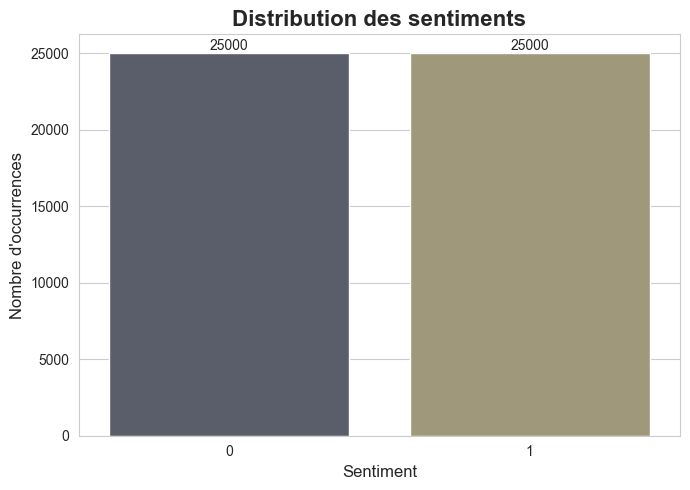

In [73]:
sentiments = df["sentiment"].value_counts()

plt.figure(figsize=(7, 5))

barplot = sns.barplot(x=sentiments.index, y=sentiments.values, palette="cividis")

plt.title("Distribution des sentiments", fontsize=16, fontweight="bold")
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Nombre d'occurrences", fontsize=12)

for container in barplot.containers:
    barplot.bar_label(container)

plt.tight_layout()
plt.show()

Dataset équilibré.

### 1.2 - Nettoyage des données
- Appliquez le nettoyage de texte complet (exercice 1)
- Normalisez les longueurs
- Vérifiez qu'il n'y a pas de missing values
- Analysez la qualité des données

In [74]:
stop_words = set(stopwords.words("english"))


def preprocessor(sentence: str) -> str:
    sentence = sentence.lower()
    sentence = re.sub(r"[^\w\s\']", "", sentence)
    sentence_tokenized = sentence.split()
    sentence = " ".join(
        [token for token in sentence_tokenized if token not in stop_words]
    )
    return sentence


df["review_cleaned"] = df["review"].apply(lambda x: preprocessor(x))
df["review_tokenized"] = df["review_cleaned"].apply(lambda x: x.split())
df["length"] = df["review_cleaned"].apply(lambda x: len(x))
df["count_token"] = df["review_tokenized"].apply(lambda x: len(x))
df.head(5)

,review,sentiment,review_cleaned,review_tokenized,length,count_token
0,? this film was just brilliant casting locatio...,1,film brilliant casting location scenery story ...,"[film, brilliant, casting, location, scenery, ...",591,89
1,? big hair big boobs bad music and a giant saf...,0,big hair big boobs bad music giant safety pin ...,"[big, hair, big, boobs, bad, music, giant, saf...",565,91
2,? this has to be one of the worst films of the...,0,one worst films 1990s friends watching film ta...,"[one, worst, films, 1990s, friends, watching, ...",396,64
3,? the ? ? at storytelling the traditional sort...,1,storytelling traditional sort many years event...,"[storytelling, traditional, sort, many, years,...",1629,244
4,? worst mistake of my life br br i picked this...,0,worst mistake life br br picked movie target 5...,"[worst, mistake, life, br, br, picked, movie, ...",442,75


In [75]:
def analyse_missing_date(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)
    df_missing = pd.DataFrame(
        {
            "Colonnes": missing.index,
            "Valeurs manquantes": missing.values,
            "Pourcentages": missing_pct.values,
        }
    )
    df_missing = df_missing[df_missing["Valeurs manquantes"] > 0].sort_values(
        "Pourcentages", ascending=False
    )
    return df_missing


missing_data = analyse_missing_date(df)
if len(missing_data) > 0:
    missing_data.head(len(missing_data))
else:
    print("Pas de valeur manqante")

Pas de valeur manqante


In [76]:
df_without_duplicates = df.drop_duplicates(subset=["review_cleaned"])
print(f"Nombre de doublons : {len(df) - len(df_without_duplicates)}")

Nombre de doublons : 426


### 1.3 - Analyse exploratoire
- Statistiques par classe
- Mots les plus fréquents positifs vs négatifs
- Word clouds par sentiment
- Longueur moyenne par classe

In [77]:
df_0 = df[df["sentiment"] == 0]
df_1 = df[df["sentiment"] == 1]

print("Statistiques descriptives label 0 :")
print(df_0[["length", "count_token"]].describe())

print("\nStatistiques descriptives label 1 :")
print(df_1[["length", "count_token"]].describe())

Statistiques descriptives label 0 :
             length   count_token
count  25000.000000  25000.000000
mean     711.227760    109.559440
std      513.860103     78.102282
min       17.000000      3.000000
25%      392.000000     61.000000
50%      539.000000     83.000000
75%      866.000000    133.000000
max     4816.000000    746.000000

Statistiques descriptives label 1 :
             length   count_token
count  25000.000000  25000.000000
mean     730.387200    110.788960
std      558.673939     83.365739
min       36.000000      5.000000
25%      385.000000     59.000000
50%      537.000000     82.000000
75%      900.000000    136.000000
max     6951.000000   1159.000000


In [78]:
count_vectorizer_0 = CountVectorizer()
X_0 = count_vectorizer_0.fit_transform(df_0["review_cleaned"])
features_count_0 = pd.DataFrame(
    {
        "features": count_vectorizer_0.get_feature_names_out(),
        "count": np.asarray(X_0.sum(axis=0)).flatten(),
    }
)

count_vectorizer_1 = CountVectorizer()
X_1 = count_vectorizer_1.fit_transform(df_1["review_cleaned"])
features_count_1 = pd.DataFrame(
    {
        "features": count_vectorizer_1.get_feature_names_out(),
        "count": np.asarray(X_1.sum(axis=0)).flatten(),
    }
)

print("Top 10 occurrence mots négatifs :")
print(features_count_0.nlargest(10, "count"))

print("\nTop 10 occurrence mots positifs :")
print(features_count_1.nlargest(10, "count"))

Top 10 occurrence mots négatifs :
     features   count
1126       br  103997
5708    movie   50043
3379     film   37547
6037      one   26251
5079     like   22449
3065     even   15249
3817     good   14668
773       bad   14667
9558    would   13995
6932   really   12350

Top 10 occurrence mots positifs :
     features  count
1128       br  97954
3382     film  42079
5713    movie  37811
6042      one  27295
5084     like  17704
3821     good  14986
3878    great  12950
8268    story  12895
8754     time  12716
9403     well  12713


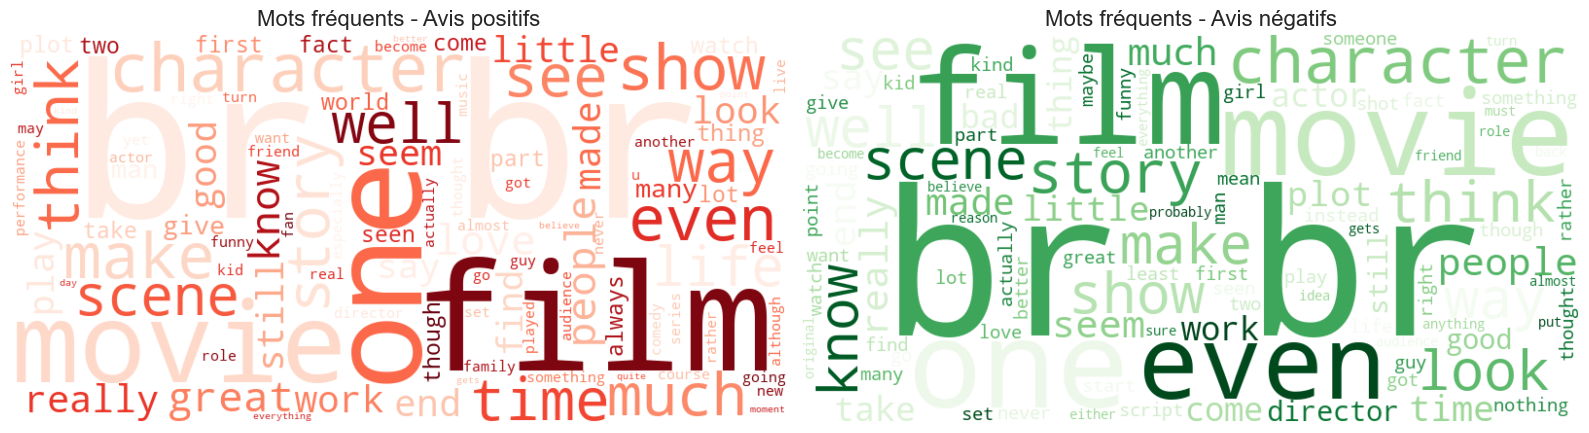

In [79]:
wordcloud_0 = WordCloud(
    width=800, height=400, background_color="white", colormap="Greens", max_words=100
).generate(df_0["review_cleaned"].str.cat(sep=" "))

wordcloud_1 = WordCloud(
    width=800, height=400, background_color="white", colormap="Reds", max_words=100
).generate(df_1["review_cleaned"].str.cat(sep=" "))

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_1, interpolation="bilinear")
plt.axis("off")
plt.title("Mots fréquents - Avis positifs", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_0, interpolation="bilinear")
plt.axis("off")
plt.title("Mots fréquents - Avis négatifs", fontsize=16)

plt.tight_layout()
plt.show()

## Phase 2 : Feature Engineering

### 2.1 - Vectorisation (rappel exercice 2)
- Appliquez TF-IDF Vectorizer
- Paramètres : max_features=5000, min_df=2
- Normalisez avec L2

In [80]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    max_features=5000,
    min_df=2,
    norm="l2",
)

X = tfidf.fit_transform(df["review_cleaned"])

### 2.2 - Features Word2Vec (rappel exercice 3)
- Entraînez Word2Vec sur le corpus
- Générez des embeddings de documents (moyenne)
- Approche alternative à TF-IDF

In [81]:
w2v = Word2Vec(
    sentences=df["review_tokenized"],
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    seed=42,
)


def get_document_embedding(tokens, model):
    valid_tokens = [t for t in tokens if t in model.wv]
    if not valid_tokens:
        return np.zeros(model.vector_size)
    return np.mean([model.wv[t] for t in valid_tokens], axis=0)


doc_embeddings = [
    get_document_embedding(sentence, w2v) for sentence in df["review_cleaned"]
]
doc_embeddings = np.array(doc_embeddings)

### 2.3 - Feature Selection
- Analysez l'importance des features
- Testez différentes dimensionnalités
- Utilisez SelectKBest si nécessaire